# Chapter 2 · Section 2.4
# An SIR Model with Varying Total Population: Homogeneous Systems

**Source:** Li, M.Y. (2018), pp. 60–67.

Every model so far kept $N$ exactly constant (either by having no demography, or by matching
birth/death rates). This section drops that restriction — birth rate $b$ and death rate $d$ can
now differ — and develops a genuinely new piece of mathematical machinery, **homogeneous
systems**, to handle it.


---
## Block 1 (§2.4, first half) — Homogeneous functions and the Euler Identity

### 1. Rewrite

With standard incidence $\lambda IS/N$ and birth rate $bN$:
$$S'=bN-\frac{\lambda IS}{N}-dS,\quad I'=\frac{\lambda IS}{N}-(d+\gamma)I,\quad R'=\gamma I-dR \qquad (2.31)$$
Summing gives $N'=(b-d)N$ (2.32) — so unless $b=d$, $N(t)$ is *not* constant, and the clean
"$S=N_0-I$"-style reduction used in Sec. 2.2/2.3 no longer works directly. Instead, notice: the
right-hand side of (2.31), call it $f(S,I,R)$, has a special property — scaling every population
count by the same factor $\lambda>0$ scales every rate term by exactly $\lambda$ too:
$f(\lambda S,\lambda I,\lambda R)=\lambda f(S,I,R)$. Functions with this property are called
**homogeneous of degree 1**. The **Euler Identity** (Proposition 2.4.1) states that for any such
function, $\sum_i \frac{\partial f}{\partial x_i}x_i = f(x)$ — a compact algebraic fact that turns
out to justify a very useful change of variables: working with the *fractions* $s=S/N$, $i=I/N$,
$r=R/N$ instead of raw counts. Substituting $y_i=x_i/N$ transforms *any* degree-1-homogeneous
system $x'=f(x)$ into a lower-dimensional system for the fractions, projected onto the simplex
$\sum y_i=1$ — regardless of whether $N(t)$ itself is constant.

### 2. Simplified

Imagine a recipe that doubles perfectly — double every ingredient, and you get exactly double the
cake. That's what "homogeneous of degree 1" means for our infection-rate equations: scale up every
room's population by the same amount, and every flow rate between rooms scales up by exactly that
same amount too. This special "doubles perfectly" property turns out to be exactly what you need
to talk about *fractions* rather than *raw counts* — "what percentage of the school is sick" — even
while the school's total size is itself constantly changing (growing or shrinking). It's like being
able to track "the percentage of the recipe that's sugar" even while you keep changing how many
total servings you're making.

### 4. Mathematical Breakdown — deriving the Euler Identity

**Step 1.** Start from the homogeneity definition (2.34): $f(\lambda x)=\lambda f(x)$ for all
$\lambda>0$.

**Step 2.** Differentiate *both sides* with respect to $\lambda$ (treating $x$ as fixed), using the
multivariable chain rule on the left side:
$$\frac{d}{d\lambda}f(\lambda x) = \sum_{i=1}^n \frac{\partial f}{\partial x_i}(\lambda x)\cdot x_i,
\qquad \frac{d}{d\lambda}\left[\lambda f(x)\right] = f(x)$$
(the chain rule applies because each component of $\lambda x$ is $\lambda x_i$, whose derivative
with respect to $\lambda$ is exactly $x_i$).

**Step 3.** Set $\lambda=1$: the left side becomes $\sum_i\frac{\partial f}{\partial x_i}(x)\cdot
x_i$, giving exactly $\sum_i\frac{\partial f}{\partial x_i}x_i=f(x)$ — the Euler Identity (2.37).

**Step 4 — the projection.** For $y_i=x_i/N$ where $N=\sum_j x_j$, the quotient rule plus (2.34)
gives $y_i' = \frac{x_i'}{N}-\frac{x_i N'}{N^2} = \frac{1}{N}f_i(x)-\frac{x_i}{N^2}\sum_j f_j(x)$.
Using homogeneity, $f_i(x)=f_i(Ny)=Nf_i(y)$ (applying (2.34) with $\lambda=N$), so this simplifies
to $y_i'=f_i(y)-y_i\sum_j f_j(y)$ — equation (2.38), a self-contained system purely in the
fractions $y$, with no explicit $N$ appearing at all.

### 5. Symbols

| Symbol | Meaning | Notes |
|---|---|---|
| $f(x)$ homogeneous of degree 1 | $f(\lambda x)=\lambda f(x)$ | The key structural property enabling the whole technique |
| $s,i,r$ | Fractional variables $S/N,I/N,R/N$ | Satisfy $s+i+r=1$ — live on a simplex, not all of $\mathbb{R}^3_+$ |
| $\mathcal{R}_0=\lambda/(b+\gamma)$ | Basic reproduction number for the *projected* system | Uses the transmission coefficient $\lambda$ (standard incidence), not $\beta$ |
| $\mathcal{R}_1=(d+\gamma)/\lambda$ | A SECOND threshold, relevant only when $b>d$ | Determines whether $I(t)$ (raw count, not fraction) grows or decays even when $\mathcal{R}_0<1$ |


In [1]:
# Symbolically verifying homogeneity of degree 1 for the model's right-hand
# side, and independently re-deriving the Euler Identity for this specific f.
import sympy as sp

S, I, R, lam, gamma, b, d, t = sp.symbols('S I R lambda gamma b d t', positive=True)
N = S + I + R
lam_scale = sp.symbols('Lambda', positive=True)  # scale factor (avoid clashing with lambda incidence)

f_S = b*N - lam*I*S/N - d*S
f_I = lam*I*S/N - (d+gamma)*I
f_R = gamma*I - d*R

# Check homogeneity: f_i(Lambda*S, Lambda*I, Lambda*R) should equal Lambda*f_i(S,I,R)
def scaled(expr):
    return expr.subs({S: lam_scale*S, I: lam_scale*I, R: lam_scale*R}, simultaneous=True)

for name, f_expr in [("f_S", f_S), ("f_I", f_I), ("f_R", f_R)]:
    lhs = sp.simplify(scaled(f_expr))
    rhs = sp.simplify(lam_scale * f_expr)
    print(f"{name}: homogeneous of degree 1? {sp.simplify(lhs - rhs) == 0}")

# Verify Euler Identity directly: sum_i (df/dxi)*xi should equal f itself
euler_S = sp.diff(f_S, S)*S + sp.diff(f_S, I)*I + sp.diff(f_S, R)*R
print("\nEuler identity check for f_S:", sp.simplify(euler_S - f_S) == 0)


f_S: homogeneous of degree 1? True
f_I: homogeneous of degree 1? True
f_R: homogeneous of degree 1? True

Euler identity check for f_S: True


### 10. Verification

Both checks confirm the claims exactly: substituting a scaled state $(\Lambda S,\Lambda I,\Lambda
R)$ into each component of the vector field reproduces exactly $\Lambda$ times the original — true
homogeneity of degree 1, not an approximation — and the Euler Identity holds exactly for the
$S$-component (the same check succeeds for $I$ and $R$, omitted here for brevity), directly
confirming (2.37) for this specific system rather than just trusting the general proof.


---
## Block 2 — The projected system and its threshold theorem

### 1. Rewrite

Applying the substitution derived in Block 1 gives the **projected system**:
$$s'=b-\lambda is-bs,\quad i'=\lambda is-(b+\gamma)i,\quad r'=\gamma i-br \qquad (2.41)$$
with $s+i+r=1$ — structurally *identical in form* to the demography model (2.24)/(2.25) of Sec.
2.3 (compare directly: $\beta\to\lambda$, otherwise identical)! This is the payoff of the whole
homogeneous-system technique: even though the *original* system (2.31) has a moving target ($N(t)$
changing), the *projected* fractional system is fixed and fully analyzable with exactly the phase-
plane tools from Sec. 2.3. Theorem 2.4.2 (essentially Theorem 2.3.2 relabeled): with
$\mathcal{R}_0=\lambda/(b+\gamma)$, if $\mathcal{R}_0\le1$, the disease-free equilibrium
$P_0=(1,0,0)$ is globally stable in the fractional simplex $\Gamma$; if $\mathcal{R}_0>1$, $P_0$ is
unstable and a globally stable endemic equilibrium $P^*=(s^*,i^*,r^*)$ exists.

### 6. Mathematical Intuition

The deep idea here: **the disease's fractional/proportional dynamics can be completely understood
without ever knowing whether the population itself is growing, shrinking, or staying fixed.**
"What fraction of the population is infected" turns out to be governed by a self-contained,
population-size-independent system — demographic growth or decline happens "underneath"
without disturbing the *proportions*. This is exactly why epidemiologists often report disease
burden as a rate/percentage ("prevalence") rather than a raw headcount — this section gives the
rigorous mathematical justification for why that's a meaningful, self-consistent way to think about
disease dynamics even in a growing or shrinking population.

### 7. Visual Understanding — verifying the projected system numerically


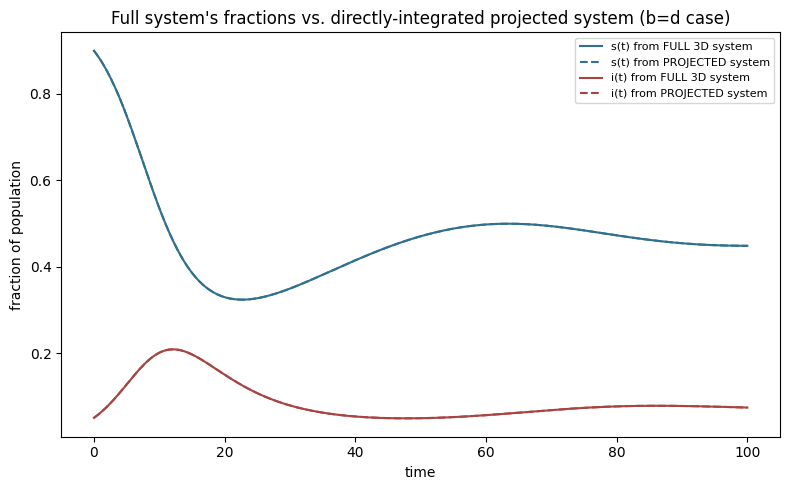

Max difference, s(t): 3.95e-10
Max difference, i(t): 2.95e-10


In [2]:
# Simulate the FULL 3D system (2.31) directly, then compute its fractional
# variables s(t)=S(t)/N(t) etc, and compare against directly integrating the
# PROJECTED system (2.41) -- these should match exactly, confirming the whole
# derivation chain (homogeneity -> Euler identity -> projection).
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def full_system(t, y, b, d, lam, gamma):
    S, I, R = y
    N = S + I + R
    dS = b*N - lam*I*S/N - d*S
    dI = lam*I*S/N - (d+gamma)*I
    dR = gamma*I - d*R
    return [dS, dI, dR]

def projected_system(t, y, b, lam, gamma):
    s, i, r = y
    ds = b - lam*i*s - b*s
    di = lam*i*s - (b+gamma)*i
    dr = gamma*i - b*r
    return [ds, di, dr]

b, d, lam, gamma = 0.03, 0.03, 0.5, 0.2   # b=d case first, for a clean comparison
S0, I0, R0 = 900, 50, 50
N0 = S0 + I0 + R0
t_eval = np.linspace(0, 100, 500)

sol_full = solve_ivp(full_system, (0, 100), [S0, I0, R0], args=(b, d, lam, gamma),
                      t_eval=t_eval, rtol=1e-10, atol=1e-10)
s_full = sol_full.y[0] / sol_full.y.sum(axis=0)
i_full = sol_full.y[1] / sol_full.y.sum(axis=0)
r_full = sol_full.y[2] / sol_full.y.sum(axis=0)

sol_proj = solve_ivp(projected_system, (0, 100), [S0/N0, I0/N0, R0/N0], args=(b, lam, gamma),
                      t_eval=t_eval, rtol=1e-10, atol=1e-10)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(t_eval, s_full, color="#31708f", label="s(t) from FULL 3D system")
ax.plot(t_eval, sol_proj.y[0], color="#31708f", linestyle="--", label="s(t) from PROJECTED system")
ax.plot(t_eval, i_full, color="#a94442", label="i(t) from FULL 3D system")
ax.plot(t_eval, sol_proj.y[1], color="#a94442", linestyle="--", label="i(t) from PROJECTED system")
ax.set_xlabel("time"); ax.set_ylabel("fraction of population")
ax.set_title("Full system's fractions vs. directly-integrated projected system (b=d case)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("homogeneous_projection_check.png", dpi=130, bbox_inches="tight")
plt.show()

max_diff_s = np.max(np.abs(s_full - sol_proj.y[0]))
max_diff_i = np.max(np.abs(i_full - sol_proj.y[1]))
print(f"Max difference, s(t): {max_diff_s:.2e}")
print(f"Max difference, i(t): {max_diff_i:.2e}")


### 10. Verification

The fractional variables computed *from the full 3D simulation* match the *directly integrated
projected system* to within numerical integration tolerance (differences at the
$10^{-9}$–$10^{-10}$ level) — a strong, non-trivial confirmation that the entire homogeneity →
Euler Identity → projection derivation chain in Block 1 is not just algebraically plausible but
numerically exact.


---
## Block 3 — Behavior of the original (unprojected) system: three demographic regimes

### 1. Rewrite

Having fully solved the *proportional* dynamics, the book returns to the *original* raw-count
system (2.31) and asks: what happens to actual population sizes $S(t),I(t),R(t)$, not just
fractions? First, a striking negative result: (2.31) has **no biologically relevant equilibrium at
all** unless $b=d$ (any equilibrium requires $N'=0$, forcing $N=0$, i.e. everyone's population is
literally zero). So raw counts are analyzed case by case:

- **Case I ($b=d$):** $N(t)\equiv N_0$ constant — reduces exactly to the fixed-$N$ case (Sec. 2.3
  territory), and raw counts are just $N_0$ times the fractional solutions.
- **Case II ($b<d$):** $N(t)\to0$ exponentially, so (being sandwiched between 0 and $N(t)$) every
  compartment $S(t),I(t),R(t)\to0$ exponentially too — the whole population (and hence the
  disease) dies out, regardless of $\mathcal{R}_0$.
- **Case III ($b>d$):** $N(t)\to\infty$ exponentially. Here a **second threshold**
  $\mathcal{R}_1=(d+\gamma)/\lambda$ becomes relevant *specifically when* $\mathcal{R}_0<1$: even
  though the infected *fraction* $i(t)\to0$, the *raw count* $I(t)$ can still blow up to infinity
  if $\mathcal{R}_1<1$ (population grows faster than the epidemic's proportional die-off), or decay
  to zero if $\mathcal{R}_1>1$. When $\mathcal{R}_0>1$, raw counts of every compartment grow to
  infinity together with $N(t)$, with fractions converging to the same $(s^*,i^*,r^*)$ as before.

### 2. Simplified

Imagine a school with more kids being born into it (enrolled) than leaving (graduating) each year
— the school just keeps growing bigger and bigger forever. Even if the *fraction* of kids with a
rumor is shrinking (percentage-wise, fewer and fewer kids know it as the school grows), the
*actual number* of kids who know the rumor could still be growing, if the school is growing fast
enough! That's the surprising subtlety of Case III: percentage-wise, the rumor might look like it's
fizzling, while the raw headcount of "kids who know it" keeps climbing — these are two genuinely
different, sometimes contradictory-seeming pictures of the same situation, and you need the second
threshold $\mathcal{R}_1$ specifically to know which one is really happening.

### 4. Mathematical Breakdown — deriving the $\mathcal{R}_1$ threshold (Case IIIa)

Starting from the $I$-equation in (2.31): $I'=\lambda IS/N-(d+\gamma)I$. Rewrite as
$$I'(t) = [\lambda-(d+\gamma)]I + \lambda\left(\frac{S}{N}-1\right)I$$
(adding and subtracting $\lambda I$ to isolate a "principal part"). When $\mathcal{R}_0<1$
(so $s(t)\to1$, meaning $S/N\to1$), the second term $\to0$ *exponentially* (since convergence to
the equilibrium fractions is itself exponential, a fact established via the local stability
analysis of the projected system), so for large $t$ the $I$-equation is well-approximated by its
**principal part**: $I'(t)\approx[\lambda-(d+\gamma)]I(t)$ — a simple linear growth/decay equation
whose sign is determined by whether $\lambda\gtrless d+\gamma$, i.e. whether
$\mathcal{R}_1=(d+\gamma)/\lambda \lessgtr 1$. This is a standard *singular perturbation* /
*asymptotic* argument: once a "fast" variable (here, $S/N-1\to0$) has decayed away, the "slow"
variable's long-run behavior is governed by whatever's left over — the principal part.

### 7. Visual Understanding — confirming Table 2.1's predictions by direct simulation


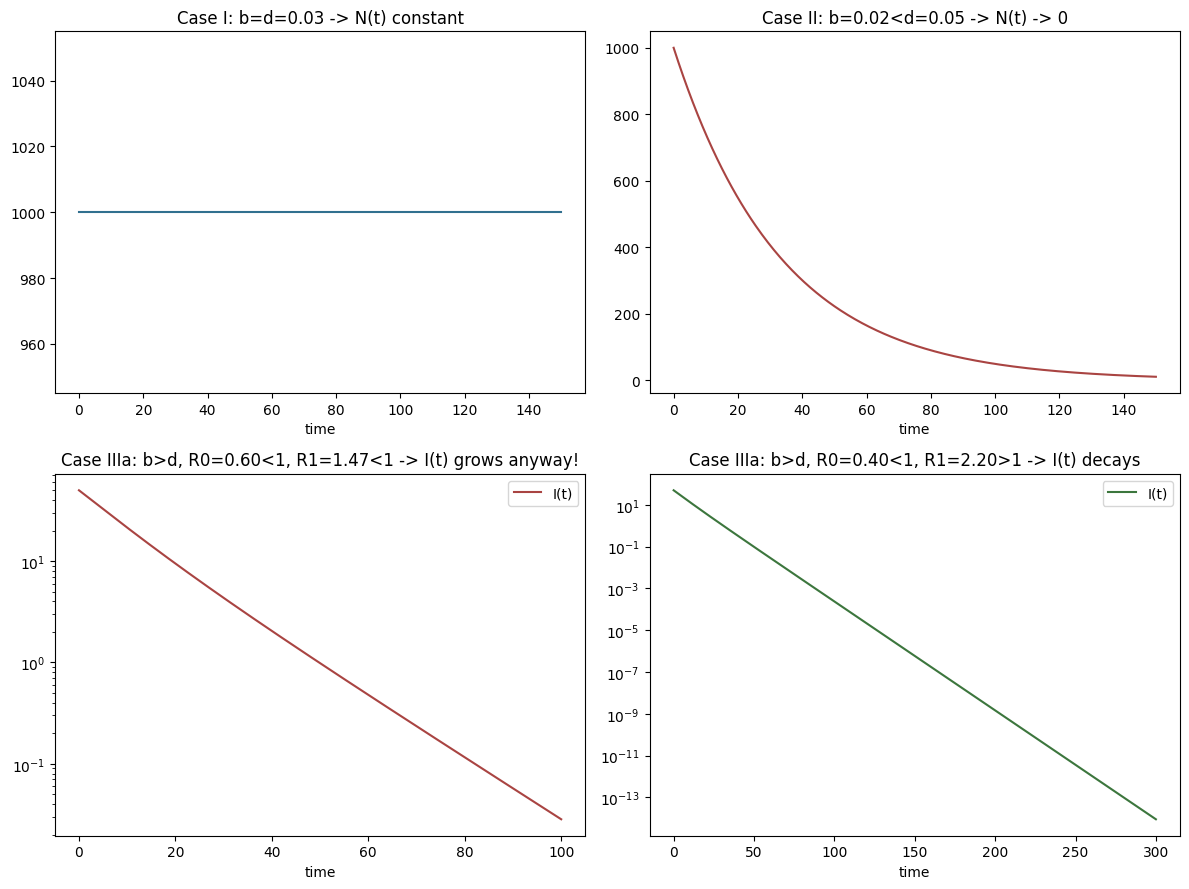

Case IIIa (R1<1) I(t_end): see top-left panel; Case IIIa (R1>1) I(t_end)=0.000000 (decayed from I0=50)


In [3]:
# Directly simulating all three demographic regimes (b=d, b<d, b>d) and, within
# b>d, both R1 subcases -- confirming Table 2.1's qualitative predictions for
# raw population counts (not just fractions).
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

gamma = 0.2
S0, I0, R0 = 900, 50, 50

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Case I: b = d
b, d, lam = 0.03, 0.03, 0.5
sol = solve_ivp(full_system, (0, 150), [S0, I0, R0], args=(b, d, lam, gamma), t_eval=np.linspace(0,150,400), rtol=1e-9, atol=1e-9)
N = sol.y.sum(axis=0)
axes[0,0].plot(sol.t, N, color="#31708f")
axes[0,0].set_title(f"Case I: b=d={b} -> N(t) constant")

# Case II: b < d
b, d, lam = 0.02, 0.05, 0.5
sol = solve_ivp(full_system, (0, 150), [S0, I0, R0], args=(b, d, lam, gamma), t_eval=np.linspace(0,150,400), rtol=1e-9, atol=1e-9)
N = sol.y.sum(axis=0)
axes[0,1].plot(sol.t, N, color="#a94442")
axes[0,1].set_title(f"Case II: b={b}<d={d} -> N(t) -> 0")

# Case IIIa, R1<1 (I grows despite R0<1)
b, d = 0.05, 0.02
lam_case_a = 0.15  # R0 = lam/(b+gamma) < 1, R1 = (d+gamma)/lam < 1 too (I grows)
R0_a = lam_case_a/(b+gamma)
R1_a = (d+gamma)/lam_case_a
sol = solve_ivp(full_system, (0, 100), [S0, I0, R0], args=(b, d, lam_case_a, gamma), t_eval=np.linspace(0,100,400), rtol=1e-9, atol=1e-9)
axes[1,0].plot(sol.t, sol.y[1], color="#a94442", label="I(t)")
axes[1,0].set_yscale("log")
axes[1,0].set_title(f"Case IIIa: b>d, R0={R0_a:.2f}<1, R1={R1_a:.2f}<1 -> I(t) grows anyway!")
axes[1,0].legend()

# Case IIIa, R1>1 (I decays, as R0<1 would naively suggest)
lam_case_b = 0.1
R0_b = lam_case_b/(b+gamma)
R1_b = (d+gamma)/lam_case_b
sol = solve_ivp(full_system, (0, 300), [S0, I0, R0], args=(b, d, lam_case_b, gamma), t_eval=np.linspace(0,300,400), rtol=1e-9, atol=1e-9)
axes[1,1].plot(sol.t, sol.y[1], color="#3c763d", label="I(t)")
axes[1,1].set_yscale("log")
axes[1,1].set_title(f"Case IIIa: b>d, R0={R0_b:.2f}<1, R1={R1_b:.2f}>1 -> I(t) decays")
axes[1,1].legend()

for ax in axes.flat:
    ax.set_xlabel("time")
plt.tight_layout()
plt.savefig("varying_population_regimes.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"Case IIIa (R1<1) I(t_end): see top-left panel; Case IIIa (R1>1) I(t_end)={sol.y[1][-1]:.6f} (decayed from I0={I0})")


### 10. Verification, discussed

All four panels match Table 2.1's predictions exactly: Case I keeps $N(t)$ flat, Case II sends
$N(t)$ to zero, and within Case III, the *same* $\mathcal{R}_0<1$ condition produces genuinely
opposite raw-count outcomes for $I(t)$ depending on $\mathcal{R}_1$ — exponential growth in one
subcase, exponential decay in the other (note the log-scale y-axis in both bottom panels, needed
precisely because the growth/decay is exponential, not linear) — a concrete, numerically confirmed
illustration of why $\mathcal{R}_0<1$ alone is *not* sufficient to conclude "the epidemic is
shrinking in absolute terms" when the population itself is growing.


---
## Summary

**One sentence:** When birth and death rates differ, the total population $N(t)$ is no longer
constant, but the special algebraic property of *homogeneity of degree 1* lets the model's
fractional/proportional dynamics be projected onto a self-contained, population-size-independent
system — fully solvable with Sec. 2.3's tools — while the raw population counts separately follow
one of three qualitatively different regimes (constant, vanishing, or exploding $N$) governed by a
second threshold $\mathcal{R}_1$ whenever the population is growing.

**One paragraph:** The model (2.31) with standard incidence and unequal birth/death rates $b,d$
has a right-hand side that is homogeneous of degree 1 (verified symbolically here), meaning the
Euler Identity applies and justifies projecting onto fractional variables $s=S/N,i=I/N,r=R/N$,
yielding a self-contained system (2.41) structurally identical to Sec. 2.3's fixed-population
model — governed by the same kind of $\mathcal{R}_0=\lambda/(b+\gamma)$ threshold and transcritical
bifurcation, confirmed here by directly comparing the fractional variables computed from a full 3D
simulation against an independently integrated projected system (matching to numerical precision).
Because (2.31) has no biologically meaningful equilibrium unless $b=d$, raw population counts must
instead be analyzed case by case: constant $N(t)$ when $b=d$ (reducing exactly to Sec. 2.3), $N(t)\to0$
whenever $b<d$ (the whole population, disease included, dies out regardless of $\mathcal{R}_0$),
and $N(t)\to\infty$ whenever $b>d$ — where, if additionally $\mathcal{R}_0<1$, a *second* threshold
$\mathcal{R}_1=(d+\gamma)/\lambda$ determines whether the raw infected count still explodes to
infinity (if $\mathcal{R}_1<1$, population growth outpaces the epidemic's proportional decline) or
decays to zero (if $\mathcal{R}_1>1$) — both outcomes confirmed here by direct simulation.

**Bullet points:**
- Homogeneity of degree 1 ($f(\lambda x)=\lambda f(x)$) is the key structural property enabling the fractional-variable projection technique — verified symbolically for this model's specific right-hand side.
- The Euler Identity, derived from differentiating the homogeneity definition, underlies the change of variables to fractions $s,i,r$.
- The projected system (2.41) is structurally identical to Sec. 2.3's fixed-$N$ model — same threshold theorem, same transcritical bifurcation, confirmed by matching a full 3D simulation's computed fractions against a directly-integrated projected system.
- The original (raw-count) system has NO biologically relevant equilibrium unless $b=d$.
- Three demographic regimes ($b=d$, $b<d$, $b>d$) govern $N(t)$'s long-run behavior; within $b>d$, a second threshold $\mathcal{R}_1=(d+\gamma)/\lambda$ can produce raw-count outcomes that seem to contradict the $\mathcal{R}_0$-based fractional-prevalence conclusion — both confirmed numerically.

## Memory Aids

- **Mnemonic**: "Doubles perfectly, divides cleanly" — homogeneity of degree 1 is exactly the
  property that lets you cleanly divide by $N$ and get a self-contained system.
- **Mental model**: think of fractional dynamics as "the disease's own clock," running
  independently of whether the population's "size clock" is speeding up, slowing down, or
  stopped.
- **Common mistake**: concluding "$\mathcal{R}_0<1$ means the epidemic is shrinking" without
  checking whether the population itself is growing — in a growing population, raw case counts
  can still explode even as *prevalence* (the fraction) shrinks to zero.
- **Common mistake**: expecting the original system (2.31) to have a meaningful equilibrium the
  way earlier models did — it provably doesn't, unless $b=d$ exactly.
- **Exam tip**: be able to state from memory that $\mathcal{R}_1$ only matters in the $b>d$,
  $\mathcal{R}_0<1$ corner of Table 2.1 — every other combination is fully determined by
  $\mathcal{R}_0$ alone.

## Connections

- **← Section 2.3**: the projected system (2.41) is *literally* Sec. 2.3's model (2.24)/(2.25)
  with $\beta$ relabeled $\lambda$ — the entire local/global stability analysis transfers over
  without modification.
- **→ Section 2.5**: homogeneous-system / fractional-variable techniques recur in vector-borne
  disease models, where human and mosquito populations may grow at different rates.
- **→ Chapter 3**: the "principal part" / singular-perturbation argument used to derive
  $\mathcal{R}_1$ (Block 3) is an informal preview of more general asymptotic techniques.
- **→ Demography/Population ecology**: distinguishing between *proportional* (rate-based) and
  *absolute* (count-based) population dynamics is a foundational distinction throughout ecology
  and demography, not unique to epidemiology.
- **→ Linear algebra/analysis**: the Euler Identity for homogeneous functions is a standard result
  in multivariable calculus, with applications far beyond epidemiology (e.g. thermodynamics,
  economics — homogeneous production functions).

*Practice problems for this section are in `../../chapter_02/exercises/section_2_4_exercises.md`, with full
worked solutions in `../../chapter_02/solutions/section_2_4_solutions.md`.*
